In [16]:
# Cell 1 — imports
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sys

import os
os.makedirs('../results', exist_ok=True)

sys.path.append('..')

# Dataset is already QC'd and filtered, so we can skip those steps. Start with normalization and clustering.
from src.preprocess import run_normalization, save_checkpoint, load_checkpoint
from src.cluster import run_clustering_pipeline
from src.visualize import plot_umap
from src.annotate import score_gene_set, export_marker_table, find_marker_genes

sc.settings.verbosity = 3
sc.settings.figdir = '../results/'

In [17]:
# Cell 2 - Load Data
adata = sc.read_h5ad('../data/SEAAD_microglia.h5ad')
print("Microglia dataset loaded") 
print(adata)

metadata = pd.read_excel('../data/SEAAD_donor_metadata.xlsx')
print("Clinical columns:")
print(metadata.columns.tolist())

neuropath = pd.read_csv('../data/SEAAD_neuropathology.csv')
print("Neuropathology columns:")
print(neuropath.columns.tolist())

print("\n--- donor ID column in adata.obs ---")
donor_cols = [c for c in adata.obs.columns if any(x in c.lower() for x in ['donor', 'external', 'specimen'])]
print(donor_cols)
print(adata.obs[donor_cols].head(5))

Microglia dataset loaded
AnnData object with n_obs × n_vars = 240651 × 36601
    obs: 'sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Inter

In [18]:
# Cell 3 - Inspecting Clinical Variables

key_clinical = [
    'Cognitive Status',
    'Braak', 
    'CERAD score',
    'Overall AD neuropathology change',
    'Thal', 
    'APOE genotype',
    'Severely Affected Donor',
    'Sex',
    'Age at Death'
]

for col in key_clinical:
    if col in adata.obs.columns:
        print(f"\n{col}:")
        print(adata.obs[col].value_counts())
    else:
        print(f"\n{col}: NOT FOUND")


Cognitive Status:
Cognitive Status
No dementia    121506
Dementia       119145
Name: count, dtype: int64

Braak:
Braak
Braak V      90805
Braak IV     59138
Braak VI     48516
Braak III    17893
Braak II     17536
Braak 0       6763
Name: count, dtype: int64

CERAD score:
CERAD score
Moderate    84540
Frequent    82094
Absent      45988
Sparse      28029
Name: count, dtype: int64

Overall AD neuropathology change: NOT FOUND

Thal:
Thal
Thal 4    85565
Thal 5    59597
Thal 3    29986
Thal 2    23599
Thal 0    23132
Thal 1    18772
Name: count, dtype: int64

APOE genotype: NOT FOUND

Severely Affected Donor:
Severely Affected Donor
N    216446
Y     24205
Name: count, dtype: int64

Sex:
Sex
Female    138684
Male      101967
Name: count, dtype: int64

Age at Death:
Age at Death
94.0     24736
93.0     18264
98.0     16639
92.0     14738
88.0     13169
91.0     12903
81.0     11046
82.0     10631
99.0     10353
97.0      9243
89.0      8491
87.0      8366
75.0      8168
80.0      7949
90.

In [19]:
# Cell 4 - Inspect Existing Cell Type Annotations

print("Subclass labels:")
print(adata.obs['Subclass'].value_counts())

print("\nSupertype labels:")
print(adata.obs['Supertype'].value_counts())

print("\nClass labels:")
print(adata.obs['Class'].value_counts())

Subclass labels:
Subclass
Microglia-PVM    240651
Name: count, dtype: int64

Supertype labels:
Supertype
Micro-PVM_2            141248
Micro-PVM_2_3-SEAAD     53815
Micro-PVM_3-SEAAD       29805
Micro-PVM_1              7909
Lymphocyte               4607
Micro-PVM_4-SEAAD        1767
Micro-PVM_2_1-SEAAD      1458
Monocyte                   42
Name: count, dtype: int64

Class labels:
Class
Non-neuronal and Non-neural    240651
Name: count, dtype: int64


In [20]:
# Cell 5 - Check normalization status of adata.X and layers['UMIs']

print("Checking adata.X (should be normalized floats):")
print(adata.X[:3, :5].toarray())

print("\nChecking layers['UMIs'] (should be raw integer counts):")
print(adata.layers['UMIs'][:3, :5].toarray())

print("\nuns keys (log1p key = already normalized):")
print(list(adata.uns.keys()))

Checking adata.X (should be normalized floats):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Checking layers['UMIs'] (should be raw integer counts):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

uns keys (log1p key = already normalized):
['Subclass_colors', 'Supertype_colors', 'log1p', 'neighbors', 'umap']


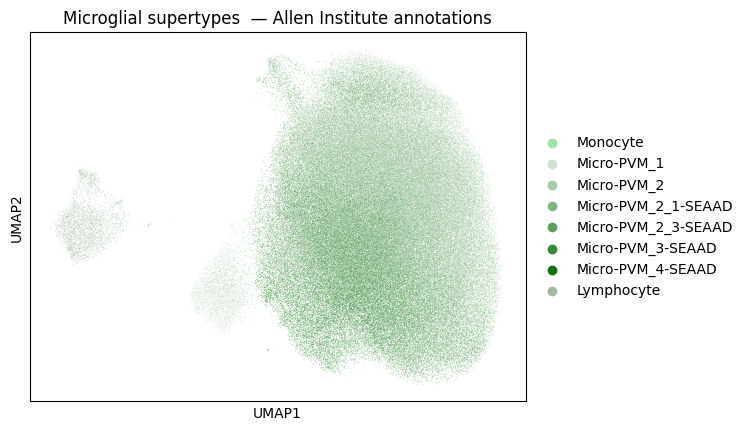

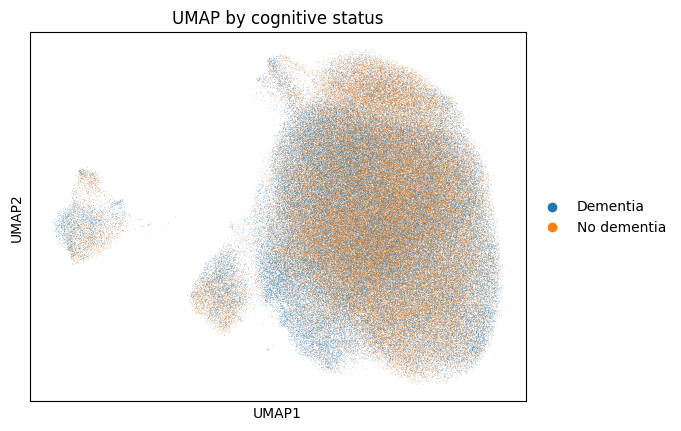

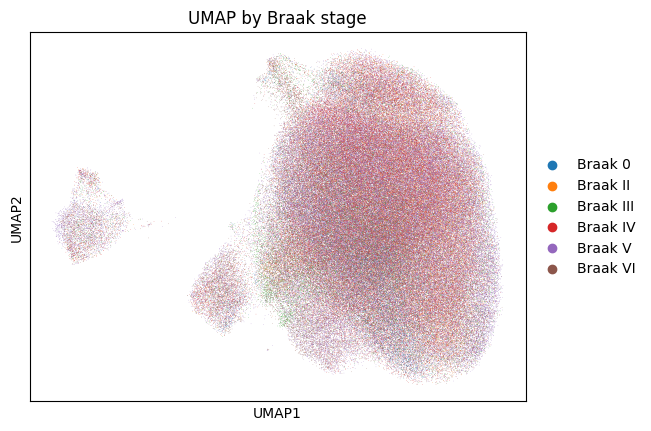

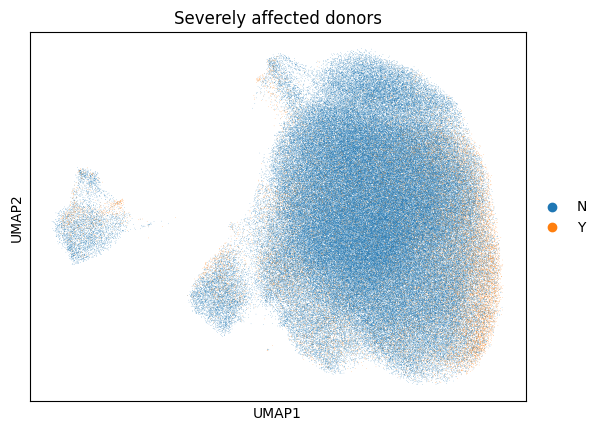

In [ ]:
# Cell 6 - Visualize existing UMAP embeddings colored by clinical variables

# color by cell supertype — Allen Institute annotations
sc.pl.umap(adata, color='Supertype',
           title='Microglial supertypes  — Allen Institute annotations')
         save = ('../results/umap_supertype.png')
    

# color by cognitive status — disease grouping
sc.pl.umap(adata, color='Cognitive Status',
           title='UMAP by cognitive status')
         save = ('../results/umap_cognitive_status.png')

# color by Braak stage — continuous disease severity
sc.pl.umap(adata, color='Braak',
           title='UMAP by Braak stage',
           color_map='RdYlBu_r')
            save = ('../results/umap_braak_stage.png')

# color by severely affected donor flag
sc.pl.umap(adata, color='Severely Affected Donor',
           title='Severely affected donors')
         save = ('../results/umap_severely_affected_donor.png')

In [15]:
# Cell 7 - Merge Neuropathology Data